MAE: 23444.98
MSE: 847631659.92
R2 Score: -0.05


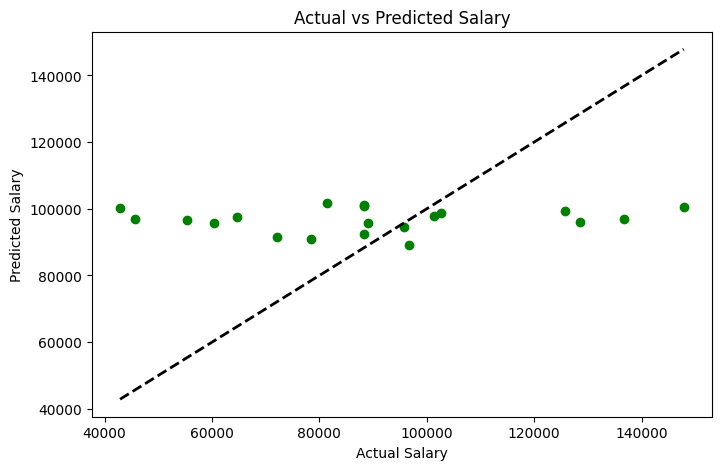

In [2]:
# revision test day_20
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 100

df = pl.DataFrame({
    "Experience": np.random.randint(1, 15, n),
    "Perf": np.random.uniform(1, 10, n),
    "Salary": np.random.randint(30000, 150000, n)
})

avg_salary = df["Salary"].mean()
df = df.with_columns(
    pl.when(pl.col("Salary") < 40000).then(None).otherwise(pl.col("Salary")).alias("Salary")
).with_columns(pl.col("Salary").fill_null(avg_salary))

X = df.select(["Experience", "Perf"]).to_numpy()
y = df.select("Salary").to_numpy().ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

df.write_csv("final_ml_data.csv")